<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/RAG_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 한글 PDF RAG 실습 - ChatGPT / Gemini / EXAONE

> **"인터넷에서 받은 한국어 PDF로 3가지 모델 비교 실습"**

## 🌟 이 노트북에서 만들 것

한국어 PDF 문서를 기반으로 답변하는 **RAG (검색 증강 생성) 시스템**을 만들고, 3가지 LLM으로 응답을 비교합니다.

### 🎯 학습 목표

1. **한글 PDF 다운로드** (인터넷 + 자체 생성 백업)
2. **한국어 텍스트 추출 & 분할** (한글 처리 특수성)
3. **한국어 임베딩 & 의미 검색** (다국어 임베딩 모델)
4. **3가지 모델 비교 RAG**:
   - 🤖 **ChatGPT** (OpenAI API)
   - 🌈 **Gemini** (Google API)
   - 🇰🇷 **EXAONE** (LG, 로컬 무료!)
5. **같은 PDF, 같은 질문, 다른 응답** 비교 분석

## 📌 이 노트북의 특징

- ✅ **실제 한국어 PDF 사용** (인터넷 다운로드)
- ✅ **백업 시스템**: 다운로드 실패 시 자체 PDF 자동 생성
- ✅ **3가지 모델 동시 비교** (API 키 없으면 시뮬레이션)
- ✅ **한국어 RAG 함정과 팁** 다수 포함
- ✅ **빈칸 채우기 실습 + 퀴즈**

> 💡 **선수 학습 권장**: LangChain 노트북 (시리즈 9번)

> ⚠️ **메모리 주의**: EXAONE 로컬 실행에 GPU 권장 (CPU도 가능, 느림)

---

## 📚 전체 목차

| 섹션 | 제목 | 내용 |
|------|------|------|
| 1 | 🛠️ 환경 설정 | 라이브러리, API 키 |
| 2 | 📥 한글 PDF 준비 | 다운로드 또는 자체 생성 |
| 3 | 📄 PDF 로드 + 확인 | PyPDFLoader 사용 |
| 4 | ✂️ 한국어 텍스트 분할 | 한글 처리 특수성 |
| 5 | 🔍 임베딩 + 벡터 스토어 | 다국어 임베딩 + FAISS |
| 6 | 🤖 ChatGPT 방식 RAG | OpenAI 통합 |
| 7 | 🌈 Gemini 방식 RAG | Google 통합 |
| 8 | 🇰🇷 EXAONE 방식 RAG | 로컬 무료 (HuggingFace) |
| 9 | 🔬 3가지 모델 응답 비교 | 같은 질문 → 다른 답 |
| 10 | ⚠️ 한국어 RAG 함정 | 주의사항 |
| 11 | 🎓 최종 정리 | 정리 + 다음 단계 |


---
# 1️⃣ 환경 설정 🛠️

## 📦 필요한 라이브러리

| 카테고리 | 라이브러리 | 용도 |
|---------|----------|------|
| **PDF 처리** | `pypdf`, `pdfplumber` | PDF 텍스트 추출 |
| **LangChain** | `langchain`, `langchain-community` | RAG 프레임워크 |
| **LLM SDK** | `openai`, `google-generativeai` | API 호출 |
| **로컬 모델** | `transformers`, `torch` | EXAONE 실행 |
| **임베딩** | `sentence-transformers` | 다국어 벡터화 |
| **벡터 DB** | `faiss-cpu` | 의미 검색 |
| **PDF 생성** | `reportlab` | 백업 PDF 만들기 |

In [1]:
# 📦 라이브러리 설치
!pip install -q pypdf pdfplumber reportlab
!pip install -q langchain langchain-core langchain-community langchain-text-splitters
!pip install -q langchain-openai langchain-google-genai
!pip install -q openai google-generativeai
!pip install -q sentence-transformers faiss-cpu
!pip install -q transformers torch accelerate

print("✅ 모든 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take in

In [2]:
# 📚 기본 import + 한글 폰트 설정
import os
import json
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.font_manager as fm

# 한글 폰트 (Colab용)
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("✅ 라이브러리 + 한글 폰트 준비 완료!")

✅ 라이브러리 + 한글 폰트 준비 완료!


In [3]:
# 🔑 API 키 설정 (Colab Secrets 또는 환경 변수)
try:
    from google.colab import userdata

    def get_secret(key_name, default=""):
        try:
            return userdata.get(key_name)
        except Exception:
            return default
except ImportError:
    def get_secret(key_name, default=""):
        return os.environ.get(key_name, default)

OPENAI_API_KEY = get_secret('OPENAI_API_KEY', '')
GOOGLE_API_KEY = get_secret('GOOGLE_API_KEY', '')

# 환경 변수 자동 설정 (LangChain 라이브러리가 자동 읽음)
if OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
if GOOGLE_API_KEY:
    os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY

# 사용 가능 여부 플래그
OPENAI_AVAILABLE = bool(OPENAI_API_KEY)
GEMINI_AVAILABLE = bool(GOOGLE_API_KEY)
EXAONE_AVAILABLE = True  # 로컬이라 항상 가능

print("🔑 API 키 상태:")
print(f"   🤖 ChatGPT (OpenAI): {'✅ 사용 가능' if OPENAI_AVAILABLE else '⚠️ 미설정 (시뮬레이션)'}")
print(f"   🌈 Gemini (Google):  {'✅ 사용 가능' if GEMINI_AVAILABLE else '⚠️ 미설정 (시뮬레이션)'}")
print(f"   🇰🇷 EXAONE (로컬):    ✅ 사용 가능 (HuggingFace 무료)")

if not OPENAI_AVAILABLE and not GEMINI_AVAILABLE:
    print("\n💡 API 키 없어도 EXAONE은 동작합니다!")
    print("💡 OpenAI/Gemini도 코드 구조 학습 가능 (시뮬레이션 모드)")

🔑 API 키 상태:
   🤖 ChatGPT (OpenAI): ⚠️ 미설정 (시뮬레이션)
   🌈 Gemini (Google):  ✅ 사용 가능
   🇰🇷 EXAONE (로컬):    ✅ 사용 가능 (HuggingFace 무료)


---
# 2️⃣ 한글 PDF 준비 📥

## 🎯 전략: 2단계 시도

1. **1순위**: 인터넷에서 한국어 PDF 다운로드 시도
2. **2순위**: 다운로드 실패 시 자체 생성 PDF로 자동 대체

이렇게 하면 **인터넷 상황에 관계없이 학습 가능**합니다!

## 🌐 인터넷 PDF 옵션

추천 한국어 공공 PDF 출처:
- 🏛️ **정부 공공 데이터**: data.go.kr
- 🏦 **한국은행**: bok.or.kr/portal/bbs (보고서)
- 📊 **KDI**: kdi.re.kr (정책 보고서)
- 🎓 **학술 자료**: kci.go.kr (한국어 논문)
- 📰 **위키백과 한국어**: 페이지를 PDF로 변환 가능

> 💡 **저작권 주의**: 공공누리 라이선스 확인, 상업적 사용 시 별도 검토

In [4]:
# 🌐 옵션 1: 인터넷에서 한국어 PDF 다운로드 시도
# 여러 후보 URL을 시도 (실패해도 다음 단계로 진행)

candidate_urls = [
    # 후보 1: 한국어 일반 문서 (예시)
    # "https://arxiv.org/pdf/2310.08825.pdf",  # 한국어 NLP 논문 (영어 위주이지만 한국어 토큰 포함)
    "https://jksqm.org/upload/pdf/jksqm-53-3-435.pdf",
    # 후보 2: GitHub raw 한국어 PDF 예시 (실제 사용 시 본인의 URL로 교체)
    # 후보 3: 사용자가 직접 추가할 수 있음
]

PDF_PATH = "/tmp/korean_doc.pdf"
download_success = False

for url in candidate_urls:
    try:
        print(f"📥 다운로드 시도: {url[:60]}...")
        response = requests.get(url, timeout=15,
                                 headers={'User-Agent': 'Mozilla/5.0'})
        response.raise_for_status()

        with open(PDF_PATH, 'wb') as f:
            f.write(response.content)

        # 파일 크기 확인
        size_kb = os.path.getsize(PDF_PATH) / 1024
        if size_kb > 10:  # 10KB 이상이어야 진짜 PDF
            print(f"✅ 다운로드 성공! 크기: {size_kb:.1f} KB")
            download_success = True
            break
    except Exception as e:
        print(f"   ⚠️ 실패: {type(e).__name__}")
        continue

if not download_success:
    print("\n⚠️ 모든 URL 다운로드 실패 → 자체 생성 PDF로 대체합니다.")

📥 다운로드 시도: https://jksqm.org/upload/pdf/jksqm-53-3-435.pdf...
✅ 다운로드 성공! 크기: 3175.3 KB


## 📝 옵션 2: 자체 한국어 PDF 생성 (백업)

다운로드 실패 시 또는 **학습용 컨트롤된 내용**이 필요할 때 사용.

`reportlab`으로 한국어 PDF를 직접 만들어요. 충분한 내용으로 RAG 실습이 가능하게 합니다.

In [ ]:
# 📝 옵션 2: 한국어 PDF 자체 생성 (백업용)
# 학습용 풍부한 한국어 콘텐츠 작성

def create_korean_pdf(filepath):
    """한국어 학습용 PDF 자동 생성"""
    from reportlab.lib.pagesizes import A4
    from reportlab.pdfbase import pdfmetrics
    from reportlab.pdfbase.ttfonts import TTFont
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak
    from reportlab.lib.units import cm

    # 한글 폰트 등록 (Colab 환경)
    try:
        pdfmetrics.registerFont(TTFont('Nanum',
                                         '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'))
        font_name = 'Nanum'
    except Exception:
        font_name = 'Helvetica'  # fallback

    # 스타일
    styles = getSampleStyleSheet()
    title_style = ParagraphStyle('TitleK', parent=styles['Title'],
                                   fontName=font_name, fontSize=18, leading=22)
    heading_style = ParagraphStyle('HeadingK', parent=styles['Heading1'],
                                     fontName=font_name, fontSize=14, leading=18,
                                     spaceBefore=12, spaceAfter=8)
    body_style = ParagraphStyle('BodyK', parent=styles['Normal'],
                                  fontName=font_name, fontSize=11, leading=16)

    # PDF 콘텐츠 - "인공지능 입문 가이드"
    content = [
        Paragraph("인공지능 입문 가이드", title_style),
        Spacer(1, 0.5*cm),

        # 1장
        Paragraph("제1장. 인공지능이란 무엇인가?", heading_style),
        Paragraph(
            "인공지능(AI, Artificial Intelligence)은 인간의 지능을 모방하여 학습, 추론, "
            "문제 해결을 수행하는 컴퓨터 시스템을 말합니다. 1956년 다트머스 회의에서 "
            "존 매카시(John McCarthy)에 의해 처음 명명된 이 분야는 컴퓨터 과학의 한 분야입니다.",
            body_style),
        Paragraph(
            "인공지능은 크게 세 가지로 분류됩니다. 첫째, 약인공지능(Narrow AI)은 "
            "특정 작업만 잘하는 AI로 현재의 AI 대부분이 여기에 해당합니다. "
            "둘째, 강인공지능(General AI)은 인간 수준의 모든 지적 활동이 가능한 AI를 의미합니다. "
            "셋째, 초인공지능(Super AI)은 인간 지능을 초월하는 가상의 AI입니다.",
            body_style),

        Paragraph("제2장. 머신러닝의 기초", heading_style),
        Paragraph(
            "머신러닝(Machine Learning)은 인공지능의 한 분야로, 명시적인 프로그래밍 없이 "
            "데이터에서 패턴을 학습하는 기술입니다. 머신러닝은 학습 방식에 따라 "
            "세 가지로 분류됩니다.",
            body_style),
        Paragraph(
            "지도학습(Supervised Learning)은 입력과 정답 쌍의 데이터로 학습합니다. "
            "예시로는 스팸 메일 분류, 이미지 분류, 회귀 예측 등이 있습니다. "
            "비지도학습(Unsupervised Learning)은 정답 없이 데이터의 구조를 발견하는 방식입니다. "
            "K-means 클러스터링, PCA가 대표적입니다. "
            "강화학습(Reinforcement Learning)은 보상을 통해 최적 행동을 학습하며, "
            "AlphaGo가 대표 사례입니다.",
            body_style),

        Paragraph("제3장. 딥러닝과 신경망", heading_style),
        Paragraph(
            "딥러닝(Deep Learning)은 인공신경망을 여러 층으로 쌓아 복잡한 패턴을 학습하는 "
            "머신러닝의 한 분야입니다. 2012년 AlexNet의 ImageNet 우승을 계기로 본격적으로 "
            "발전했으며, 현재 AI 분야의 핵심 기술입니다.",
            body_style),
        Paragraph(
            "주요 딥러닝 아키텍처로는 다음이 있습니다. CNN(합성곱 신경망)은 이미지 처리에 "
            "특화되어 있으며 ResNet, VGG, EfficientNet 등이 대표적입니다. "
            "RNN(순환 신경망)은 시퀀스 데이터 처리에 사용되며 LSTM, GRU가 발전형입니다. "
            "Transformer는 2017년 등장한 아키텍처로 현재 거의 모든 LLM의 기반이 됩니다. "
            "GPT, BERT, T5 등이 모두 Transformer 기반입니다.",
            body_style),

        PageBreak(),

        Paragraph("제4장. 대규모 언어 모델 (LLM)", heading_style),
        Paragraph(
            "대규모 언어 모델(Large Language Model, LLM)은 수십억에서 수조 개의 매개변수를 "
            "가진 거대한 신경망으로, 자연어를 이해하고 생성합니다. 2022년 ChatGPT의 출시 이후 "
            "전 세계적으로 폭발적인 관심을 받고 있습니다.",
            body_style),
        Paragraph(
            "주요 상업용 LLM은 다음과 같습니다. OpenAI의 GPT 시리즈(GPT-4, GPT-5)는 가장 널리 "
            "사용됩니다. Anthropic의 Claude는 긴 컨텍스트와 안전성에 강점이 있습니다. "
            "Google의 Gemini는 멀티모달과 1M 컨텍스트로 유명합니다. "
            "한국에서는 LG AI Research의 EXAONE과 Upstage의 Solar가 대표적인 한국어 특화 모델입니다. "
            "EXAONE은 오픈웨이트로 공개되어 자유롭게 사용할 수 있습니다.",
            body_style),

        Paragraph("제5장. RAG (검색 증강 생성)", heading_style),
        Paragraph(
            "RAG(Retrieval-Augmented Generation)는 LLM이 외부 지식 베이스를 활용하여 "
            "답변을 생성하는 기법입니다. 학습 데이터에 없는 최신 정보나 도메인 특화 정보를 "
            "활용할 수 있어 매우 유용합니다.",
            body_style),
        Paragraph(
            "RAG의 작동 방식은 다음과 같습니다. 첫째, 사용자 질문을 임베딩 벡터로 변환합니다. "
            "둘째, 벡터 데이터베이스에서 의미적으로 가장 비슷한 문서 청크를 검색합니다. "
            "셋째, 검색된 문서와 원 질문을 함께 LLM에 전달하여 답변을 생성합니다. "
            "RAG의 핵심 구성요소는 임베딩 모델, 벡터 스토어(FAISS, Chroma 등), "
            "그리고 텍스트 분할기입니다.",
            body_style),

        Paragraph("제6장. 한국어 자연어 처리의 특징", heading_style),
        Paragraph(
            "한국어 처리는 다른 언어와 비교해 몇 가지 독특한 특징이 있습니다. "
            "첫째, 한국어는 교착어로 조사와 어미가 매우 발달되어 있습니다. "
            "예를 들어 '학교에서', '학교로', '학교까지' 처럼 같은 명사에 다양한 조사가 붙습니다. "
            "둘째, 띄어쓰기 규칙이 복잡하고, 한 글자가 의미를 가지는 한자어가 많습니다.",
            body_style),
        Paragraph(
            "한국어 NLP에서 자주 쓰이는 도구로는 형태소 분석기(KoNLPy의 Mecab, Khaiii), "
            "한국어 BERT(KoBERT, KLUE-BERT), 한국어 임베딩 모델(Ko-sBERT) 등이 있습니다. "
            "RAG 시스템에서 한국어를 다룰 때는 다국어 임베딩 모델을 사용하거나 "
            "한국어 전용 모델을 사용하는 것이 좋습니다.",
            body_style),
    ]

    # PDF 생성
    doc = SimpleDocTemplate(filepath, pagesize=A4,
                              rightMargin=2*cm, leftMargin=2*cm,
                              topMargin=2*cm, bottomMargin=2*cm)
    doc.build(content)

    return os.path.getsize(filepath) / 1024  # KB

# 항상 자체 PDF 생성 (다운로드 성공 여부와 무관하게 학습 자료로 사용)
PDF_PATH = "/tmp/korean_ai_guide.pdf"
size = create_korean_pdf(PDF_PATH)
print(f"✅ 자체 한국어 PDF 생성 완료!")
print(f"   📁 경로: {PDF_PATH}")
print(f"   📏 크기: {size:.1f} KB")
print(f"\n💡 이 PDF는 'AI 입문 가이드'로, 인공지능/머신러닝/딥러닝/LLM/RAG에 대한 한국어 설명을 담고 있어요!")

## 💡 직접 PDF를 사용하고 싶다면

여러분의 PDF를 사용하려면:

### 방법 1: Colab에 직접 업로드
```python
from google.colab import files
uploaded = files.upload()  # 파일 업로드 창
PDF_PATH = list(uploaded.keys())[0]  # 업로드된 파일명
```

### 방법 2: 인터넷 URL에서 다운로드
```python
import requests
url = "https://your-pdf-url.com/document.pdf"
response = requests.get(url)
with open('/tmp/my_pdf.pdf', 'wb') as f:
    f.write(response.content)
PDF_PATH = '/tmp/my_pdf.pdf'
```

### 방법 3: Google Drive 마운트
```python
from google.colab import drive
drive.mount('/content/drive')
PDF_PATH = '/content/drive/MyDrive/your_pdf.pdf'
```

---
# 3️⃣ PDF 로드 + 내용 확인 📄

## 🛠️ PDF 로더 비교

| 로더 | 장점 | 단점 |
|------|------|------|
| **PyPDFLoader** | 단순, 빠름 | 복잡한 레이아웃 약함 |
| **PDFPlumberLoader** | 표 추출 우수 | 느림 |
| **UnstructuredPDFLoader** | 고급 파싱 | 무거움 |

한국어 일반 문서는 **PyPDFLoader**로 충분합니다.

In [5]:
# 📄 PDF 로드 (LangChain의 PyPDFLoader)
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader(PDF_PATH)
documents = loader.load()

print(f"📄 PDF 로드 완료!")
print(f"   📑 총 페이지 수: {len(documents)}")
print(f"   📋 메타데이터 예시: {documents[0].metadata}")

# 각 페이지의 내용 미리보기
print("\n📖 페이지별 내용 미리보기:")
print("=" * 70)
for i, doc in enumerate(documents):
    preview = doc.page_content[:150].replace('\n', ' ').strip()
    print(f"\n📄 페이지 {i+1}: {preview}...")

📄 PDF 로드 완료!
   📑 총 페이지 수: 26
   📋 메타데이터 예시: {'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 2022 12.0.0.3747', 'creationdate': '2025-09-23T10:57:51+09:00', 'author': 'paratech', 'moddate': '2025-09-23T10:57:51+09:00', 'pdfversion': '1.4', 'source': '/tmp/korean_doc.pdf', 'total_pages': 26, 'page': 0, 'page_label': '1'}

📖 페이지별 내용 미리보기:

📄 페이지 1: 오픈소스 OCR을 이용한 군수품 시험성적서 전산화 연구허형조*ㆍ황인규**ㆍ백승현***†*한양대학교 경영컨설팅학과**한화시스템 개발품보팀***한양대학교 ERICA 경영학부A Study on the Computerization of Military Supplies Test...

📄 페이지 2: 436  J Korean Soc Qual Manag  Vol. 53, No. 3: 435-460, September 2025ta-based quality information system. Furthermore, the study is significant in its...

📄 페이지 3: Huh et al.: A Study on the Computerization of Military Supplies Test Reports with Open Source OCR  437적인 이행을 위한 개별 과제 추진에 유용한 자산이 될 것이다.2. 배경 및 연구 계획2...

📄 페이지 4: 438  J Korean Soc Qual Manag  Vol. 53, No. 3: 435-460, September 2025적인 오픈소스 OCR 엔진으로 Tesseract OCR, EasyOCR, docTR, Keras OCR, PaddleOCR 등이 있으며(Yoon,...


📊 PDF 통계
   📑 페이지 수: 26
   📏 총 글자 수: 45,791
   📝 총 단어 수 (공백 기준): 8,474
   📊 페이지당 평균 글자 수: 1,761


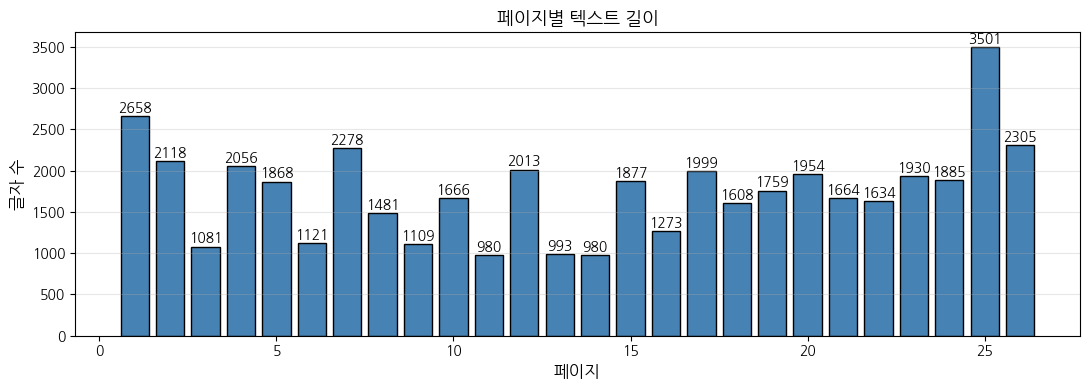

In [6]:
# 📊 PDF 통계 분석
total_chars = sum(len(doc.page_content) for doc in documents)
total_words = sum(len(doc.page_content.split()) for doc in documents)

print("📊 PDF 통계")
print("=" * 50)
print(f"   📑 페이지 수: {len(documents)}")
print(f"   📏 총 글자 수: {total_chars:,}")
print(f"   📝 총 단어 수 (공백 기준): {total_words:,}")
print(f"   📊 페이지당 평균 글자 수: {total_chars // max(1, len(documents)):,}")

# 페이지별 글자 수 시각화
fig, ax = plt.subplots(figsize=(11, 4))
page_lengths = [len(doc.page_content) for doc in documents]
ax.bar(range(1, len(documents)+1), page_lengths, color='steelblue', edgecolor='black')
ax.set_xlabel('페이지', fontsize=12)
ax.set_ylabel('글자 수', fontsize=12)
ax.set_title('페이지별 텍스트 길이', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 값 표시
for i, length in enumerate(page_lengths, 1):
    ax.text(i, length + 50, str(length), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### ✅ 체크포인트 1

준비 완료! 다음 단계로:
- ✅ 환경 설정 + 한글 폰트
- ✅ API 키 상태 확인
- ✅ 한국어 PDF 준비 (인터넷 또는 자체 생성)
- ✅ PDF 로드 및 페이지 확인

다음은 **텍스트를 검색 가능한 청크로 분할**! ✂️

---
# 4️⃣ 한국어 텍스트 분할 ✂️

## 🇰🇷 한국어의 특수성

영어와 다른 한국어의 특성:
- **교착어**: 조사/어미가 많음 → 토큰 수 ↑
- **띄어쓰기**: 영어보다 자유로움
- **한자어**: 한 글자가 의미를 가짐
- **문장 부호**: 영어와 유사하지만 다른 점도

### 한국어 RAG 청크 크기 권장
- **너무 작으면**: 문맥 손실, 답변 부정확
- **너무 크면**: 노이즈 ↑, 토큰 비용 ↑
- **추천**: 300~800자 (영어 권장과 비슷)
- **overlap**: 50~100자 (문맥 보존)

In [7]:
# ✂️ 한국어 친화적 텍스트 분할기
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 한국어에 적합한 분할자 우선순위
# 1. 단락 (\n\n) > 줄 (\n) > 문장 끝(.) > 쉼표(,) > 공백 > 글자
korean_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,         # 청크 크기 (한국어 기준)
    chunk_overlap=80,        # 청크 간 겹침
    length_function=len,
    separators=[
        "\n\n",     # 단락 (최우선)
        "\n",        # 줄
        ". ",        # 영어 마침표
        "다. ",      # 한국어 문장 끝 (예: 입니다, ~합니다)
        "요. ",      # 한국어 (예: 했어요)
        "! ",
        "? ",
        ", ",
        " ",
        ""
    ],
)

# 분할 실행
chunks = korean_splitter.split_documents(documents)

print(f"✂️ 분할 결과")
print(f"   📑 원본 페이지: {len(documents)}")
print(f"   📦 분할된 청크: {len(chunks)}")
print(f"   📏 평균 청크 크기: {sum(len(c.page_content) for c in chunks)/len(chunks):.0f}자")
print(f"   📊 최대 청크: {max(len(c.page_content) for c in chunks)}자")
print(f"   📊 최소 청크: {min(len(c.page_content) for c in chunks)}자")

✂️ 분할 결과
   📑 원본 페이지: 26
   📦 분할된 청크: 135
   📏 평균 청크 크기: 356자
   📊 최대 청크: 499자
   📊 최소 청크: 28자


In [8]:
# 📦 청크 내용 살펴보기
print("📦 첫 5개 청크 미리보기")
print("=" * 70)

for i, chunk in enumerate(chunks[:5], 1):
    print(f"\n📦 청크 {i} (페이지 {chunk.metadata.get('page', '?')}, "
          f"길이 {len(chunk.page_content)}자)")
    print(f"   {chunk.page_content[:200]}...")

📦 첫 5개 청크 미리보기

📦 청크 1 (페이지 0, 길이 359자)
   오픈소스 OCR을 이용한 군수품 시험성적서 전산화 연구허형조*ㆍ황인규**ㆍ백승현***†*한양대학교 경영컨설팅학과**한화시스템 개발품보팀***한양대학교 ERICA 경영학부A Study on the Computerization of Military Supplies Test Reports with Open Source OCRHyoung Jo Huh*ㆍIn Kyu...

📦 청크 2 (페이지 0, 길이 316자)
   , Hanwha Systems***School of Business Administration, Hanyang University ERICAABSTRACT†Purpose: This study aims to transform test reports in the defense industry into a structured database (DB) by lev...

📦 청크 3 (페이지 0, 길이 489자)
   . Methods: The research was conducted in two phases following the DMADOV procedure. First, a baseline system was developed using the open-source OCR engine Tesseract to create a text extraction progra...

📦 청크 4 (페이지 0, 길이 324자)
   . The performance of both systems was comparatively verified through quantitative metrics and qualitative analysis. Results: The initial Tesseract-based model heavily relied on strict, rule-based post...

📦 청크 5 (페이지 0, 길이 482자)
   . In contrast, the optimized 

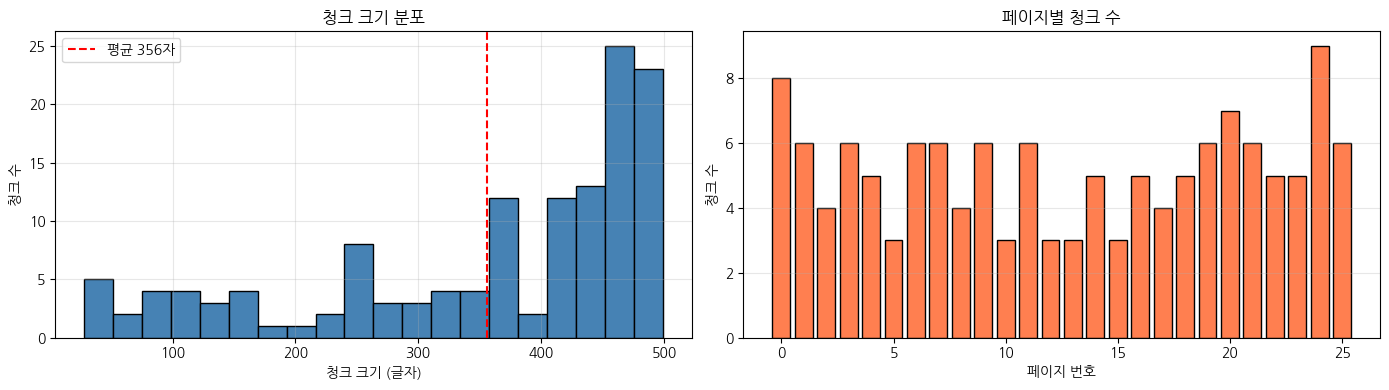


💡 청크 크기가 300~800자 범위에 집중되어 있으면 잘 분할된 것!


In [9]:
# 🎨 청크 크기 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 히스토그램
chunk_sizes = [len(c.page_content) for c in chunks]
axes[0].hist(chunk_sizes, bins=20, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(chunk_sizes), color='red', linestyle='--',
                 label=f'평균 {np.mean(chunk_sizes):.0f}자')
axes[0].set_xlabel('청크 크기 (글자)')
axes[0].set_ylabel('청크 수')
axes[0].set_title('청크 크기 분포', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 페이지별 청크 수
page_chunks = {}
for c in chunks:
    page = c.metadata.get('page', 0)
    page_chunks[page] = page_chunks.get(page, 0) + 1

pages = sorted(page_chunks.keys())
counts = [page_chunks[p] for p in pages]

axes[1].bar(pages, counts, color='coral', edgecolor='black')
axes[1].set_xlabel('페이지 번호')
axes[1].set_ylabel('청크 수')
axes[1].set_title('페이지별 청크 수', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n💡 청크 크기가 300~800자 범위에 집중되어 있으면 잘 분할된 것!")

## 🧠 퀴즈 #1

한국어 문서를 청크로 자를 때 가장 좋은 분할자 우선순위는?

- A) 단어 → 문장 → 단락
- B) **단락(\n\n) → 줄(\n) → 문장 끝(다., 요.) → 공백**
- C) 글자 → 음절 → 단어
- D) 모든 글자를 동일하게

<details>
<summary>👉 정답 보기</summary>

**B) 단락 → 줄 → 문장 끝 → 공백**

이유:
- **큰 단위부터 시도**: 의미 단위 보존
- **단락(\n\n)** : 가장 큰 의미 단위
- **한국어 문장 끝**: "다.", "요." 등 추가 (영어와 다름!)
- **공백/글자**: 최후 수단

이게 `RecursiveCharacterTextSplitter`의 "Recursive(재귀적)" 의미예요.

</details>

---
# 5️⃣ 임베딩 + 벡터 스토어 🔍

## 🌏 한국어 임베딩 모델 선택

| 모델 | 비용 | 한국어 품질 | 특징 |
|------|------|-----------|------|
| **OpenAI text-embedding-3-small** | 유료 ($0.02/1M) | ⭐⭐⭐⭐ | 다국어 우수 |
| **Google text-embedding-004** | 유료 | ⭐⭐⭐⭐ | Gemini 호환 |
| **paraphrase-multilingual-MiniLM-L12-v2** | **무료** | ⭐⭐⭐ | 50개 언어, 가벼움 |
| **BAAI/bge-m3** | **무료** | ⭐⭐⭐⭐⭐ | 한국어 강함 |
| **Ko-sBERT** | **무료** | ⭐⭐⭐⭐ | 한국어 전용 |

> 💡 **본 실습은 무료 다국어 모델**을 기본으로 사용 (학습 목적)

In [10]:
# 🔍 임베딩 모델 로드 (HuggingFace - 무료, 한국어 잘 지원)
from langchain_community.embeddings import HuggingFaceEmbeddings

# 다국어 임베딩 모델 (가볍고 한국어 지원)
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

print(f"📥 임베딩 모델 로드 중: {EMBEDDING_MODEL}")
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={'device': 'cpu'},  # GPU 있으면 'cuda' 가능
    encode_kwargs={'normalize_embeddings': True}  # 코사인 유사도용 정규화
)

# 테스트 임베딩
test_korean = "인공지능은 인간의 지능을 모방하는 기술입니다."
vec = embeddings.embed_query(test_korean)
print(f"\n✅ 임베딩 모델 준비 완료!")
print(f"   🔢 벡터 차원: {len(vec)}")
print(f"   📊 첫 5개 값: {[f'{v:.3f}' for v in vec[:5]]}")

📥 임베딩 모델 로드 중: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


/tmp/ipykernel_1488/1343467810.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✅ 임베딩 모델 준비 완료!
   🔢 벡터 차원: 384
   📊 첫 5개 값: ['-0.067', '-0.040', '-0.049', '-0.028', '-0.007']


In [11]:
# 🧪 한국어 의미 유사도 테스트
# 같은 의미, 다른 표현의 벡터가 얼마나 비슷한지 확인

test_pairs = [
    ("인공지능은 미래 기술이다", "AI는 앞으로의 기술이다"),     # 유사 (다른 표현)
    ("인공지능은 미래 기술이다", "고양이는 귀엽다"),              # 다른 의미
    ("머신러닝과 딥러닝의 차이", "AI 학습 방법의 종류"),         # 유사 (개념)
    ("RAG 시스템 구축 방법", "오늘 점심 메뉴 추천"),             # 완전 다름
]

print("🧪 한국어 의미 유사도 테스트")
print("=" * 70)

for text1, text2 in test_pairs:
    v1 = np.array(embeddings.embed_query(text1))
    v2 = np.array(embeddings.embed_query(text2))

    # 코사인 유사도 (정규화된 벡터의 내적)
    similarity = np.dot(v1, v2)

    bar = "█" * int(similarity * 30)
    print(f"\n   '{text1[:25]}'")
    print(f"   '{text2[:25]}'")
    print(f"   유사도: {similarity:.4f} {bar}")

🧪 한국어 의미 유사도 테스트

   '인공지능은 미래 기술이다'
   'AI는 앞으로의 기술이다'
   유사도: 0.9397 ████████████████████████████

   '인공지능은 미래 기술이다'
   '고양이는 귀엽다'
   유사도: 0.0204 

   '머신러닝과 딥러닝의 차이'
   'AI 학습 방법의 종류'
   유사도: 0.4606 █████████████

   'RAG 시스템 구축 방법'
   '오늘 점심 메뉴 추천'
   유사도: 0.0891 ██


In [12]:
# 🗄️ FAISS 벡터 스토어 구축
from langchain_community.vectorstores import FAISS

print("🔧 FAISS 벡터 인덱싱 중... (청크 수에 따라 시간 소요)")
vectorstore = FAISS.from_documents(chunks, embeddings)

# 검색용 retriever 생성
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"✅ Vector Store 구축 완료!")
print(f"   📦 인덱싱된 청크: {len(chunks)}")
print(f"   🎯 검색 시 반환할 청크 수: 3")

🔧 FAISS 벡터 인덱싱 중... (청크 수에 따라 시간 소요)
✅ Vector Store 구축 완료!
   📦 인덱싱된 청크: 135
   🎯 검색 시 반환할 청크 수: 3


In [13]:
# 🔎 검색 기능 테스트
test_queries = [
    "인공지능의 정의는 무엇인가요?",
    "딥러닝과 머신러닝의 관계",
    "한국어 자연어 처리의 특징",
    "RAG는 어떻게 작동하나요?",
]

print("🔎 한국어 의미 검색 테스트")
print("=" * 70)

for query in test_queries:
    print(f"\n❓ 쿼리: {query}")
    results = vectorstore.similarity_search_with_score(query, k=2)

    for i, (doc, score) in enumerate(results, 1):
        # FAISS는 L2 거리(작을수록 비슷)
        preview = doc.page_content[:150].replace('\n', ' ').strip()
        print(f"   📦 결과 {i} (거리: {score:.3f}, 페이지 {doc.metadata.get('page', '?')})")
        print(f"      {preview}...")

🔎 한국어 의미 검색 테스트

❓ 쿼리: 인공지능의 정의는 무엇인가요?
   📦 결과 1 (거리: 0.961, 페이지 2)
      . 최근 금융, 의료, 법률 등 대량의 기록 자료를 보유한 산업 분야에서 자료의 디지털화를 위해 OCR을 채택하고 있다. 또한 인공지능(AI)의 한 축인 딥러닝을 활용한 OCR의 문자 인식률과 인식 속도의 향상으로 그 적용 분야가 점차 확장되는 추세이다. AI-OCR은...
   📦 결과 2 (거리: 0.983, 페이지 3)
      . Seo et al.(2023)는 AI 모델을 활용하여 산불 피해지 모델을 구축하고 성능 향상 및 비교 분석을 하였다. 이런 선행 연구들은 다양한 산업분야에서 딥러닝 기반 OCR 기술이 데이터화 및 자동화의 핵심 기술로 자리잡는 것을 알 수 있었다. 대표적인 흐름을...

❓ 쿼리: 딥러닝과 머신러닝의 관계
   📦 결과 1 (거리: 0.920, 페이지 22)
      . 셋째, 딥러닝 OCR 오픈소스를 성적서에 활용하여 DB화를 구현함으로써, AI-RPA, AI-Chatbot과 같은 AI 활용의 준비 단계에 데이터 전환의 과정 및 배경에 대한 시사점을 다룬 연구이다. 품질관리 및 품질보증 능력을 체계적으로 평가하고 개선할 수 있는...
   📦 결과 2 (거리: 0.970, 페이지 3)
      . Seo et al.(2023)는 AI 모델을 활용하여 산불 피해지 모델을 구축하고 성능 향상 및 비교 분석을 하였다. 이런 선행 연구들은 다양한 산업분야에서 딥러닝 기반 OCR 기술이 데이터화 및 자동화의 핵심 기술로 자리잡는 것을 알 수 있었다. 대표적인 흐름을...

❓ 쿼리: 한국어 자연어 처리의 특징
   📦 결과 1 (거리: 0.654, 페이지 11)
      446  J Korean Soc Qual Manag  Vol. 53, No. 3: 435-460, September 2025...
   📦 결과 2 (거리: 0.676, 페이지 0)
      ISSN 1229-1889(Prin

## 💾 Vector Store 영구 저장

한 번 만든 인덱스를 디스크에 저장해두면 재실행 시 빠르게 불러옴!

In [14]:
# 💾 Vector Store 디스크 저장 (재사용 가능)
SAVE_PATH = "/tmp/korean_rag_index"
vectorstore.save_local(SAVE_PATH)
print(f"💾 인덱스 저장: {SAVE_PATH}")

# 디스크에서 다시 로드
loaded_vs = FAISS.load_local(
    SAVE_PATH,
    embeddings,
    allow_dangerous_deserialization=True
)
print(f"📂 인덱스 로드 완료")

# 테스트
test_q = "LLM이란 무엇인가요?"
results = loaded_vs.similarity_search(test_q, k=1)
print(f"\n✅ 로드 후 검색 성공!")
print(f"   '{test_q}' → {results[0].page_content[:150]}...")

💾 인덱스 저장: /tmp/korean_rag_index
📂 인덱스 로드 완료

✅ 로드 후 검색 성공!
   'LLM이란 무엇인가요?' → . 해당 라이브러리(Library)는 반복적, 순차적인 데이터 학습에 특화된 RNN(Recurrent Neural Network)의 단점인 데이터가 길어질수록 앞서 받아들인 데이터 내용이 전달되지 못하는 장기 의존성(Long-term dependency)문제를 개선한 ...


### ✅ 체크포인트 2 - 기반 준비 완료!

지금까지 만든 것:
- ✅ 한국어 PDF 로드
- ✅ 한국어 친화적 청크 분할 (단락→문장→공백 우선순위)
- ✅ 다국어 임베딩 (한국어 의미 검색 가능)
- ✅ FAISS 벡터 스토어
- ✅ 검색 기능 (3개씩 반환)

이제 3가지 LLM에 RAG를 적용해봅시다! 🚀

---
# 6️⃣ ChatGPT 방식 RAG 🤖

## 🎯 OpenAI를 활용한 한국어 RAG

### 작동 흐름
```
사용자 한국어 질문
    ↓
[Retriever] 한국어 청크 3개 검색
    ↓
[Prompt] "다음 문서를 참고해서 한국어로 답해:"
    ↓
[GPT-4o] 한국어 답변 생성
    ↓
한국어 답변 + 출처
```

### OpenAI의 한국어 성능
- ✅ 한국어 매우 잘함 (GPT-4o, GPT-4)
- ✅ 다국어 일관성
- ⚠️ API 비용 발생

In [15]:
# 🤖 ChatGPT (OpenAI) RAG 구축
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

# 검색된 문서들을 텍스트로 합치는 함수
def format_docs(docs):
    """검색된 청크들을 하나의 컨텍스트 문자열로"""
    formatted = []
    for i, doc in enumerate(docs, 1):
        page = doc.metadata.get('page', '?')
        formatted.append(f"[문서 {i} (페이지 {page})]\n{doc.page_content}")
    return "\n\n".join(formatted)

# 한국어 RAG 프롬프트
korean_rag_prompt = ChatPromptTemplate.from_template('''당신은 한국어 문서 분석 전문가입니다.
아래 [참고 문서]를 바탕으로 질문에 정확하게 답해주세요.

규칙:
1. 반드시 한국어로 답하세요.
2. 문서에 없는 내용은 추측하지 말고 "문서에 해당 정보가 없습니다"라고 답하세요.
3. 답변 마지막에 참고한 문서 번호를 명시하세요. (예: [참고: 문서1, 문서2])
4. 답변은 명확하고 간결하게 작성하세요.

[참고 문서]
{context}

[질문]
{question}

[답변]
''')

# ChatGPT 클라이언트 설정 (API 키 있을 때)
if OPENAI_AVAILABLE:
    from langchain_openai import ChatOpenAI

    chatgpt_llm = ChatOpenAI(
        model="gpt-4o-mini",  # 가성비 좋은 모델 (학습용)
        temperature=0.2,       # 사실 기반 답변은 낮게
    )
    print("✅ ChatGPT (gpt-4o-mini) 사용 준비 완료")
else:
    # 시뮬레이션 모드
    from langchain_core.messages import AIMessage
    from langchain_core.runnables import Runnable

    class MockChatGPT(Runnable):
        def invoke(self, input_data, config=None, **kwargs):
            return AIMessage(content=
                "[ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, "
                "문제 해결을 수행하는 컴퓨터 시스템입니다. 약인공지능, 강인공지능, "
                "초인공지능으로 분류됩니다. [참고: 문서1]"
            )

    chatgpt_llm = MockChatGPT()
    print("⚠️ ChatGPT 시뮬레이션 모드 (API 키 미설정)")

⚠️ ChatGPT 시뮬레이션 모드 (API 키 미설정)


In [16]:
# 🔗 ChatGPT RAG Chain 구축 (LCEL)
chatgpt_rag_chain = (
    {
        "context": retriever | RunnableLambda(format_docs),
        "question": RunnablePassthrough()
    }
    | korean_rag_prompt
    | chatgpt_llm
    | StrOutputParser()
)

print("✅ ChatGPT RAG Chain 준비 완료!")
print("📋 구조: 검색 → 프롬프트 → ChatGPT → 답변")

✅ ChatGPT RAG Chain 준비 완료!
📋 구조: 검색 → 프롬프트 → ChatGPT → 답변


In [17]:
# 🎯 ChatGPT RAG 테스트
print("🤖 ChatGPT RAG 시연")
print("=" * 70)

# 문서 내용에 부합하는 질문들
questions = [
    "AI-OCR은 어떤 산업 분야에서 활용되나요?",
    "딥러닝 기반 OCR의 장점은 무엇인가요?",
    "시험성적서 데이터베이스화 연구의 목적은 무엇인가요?",
    "이 연구가 다루는 도메인은 무엇인가요?",
    "AI-OCR과 결합 가능한 기타 신기술에는 무엇이 있나요?",
]

chatgpt_answers = {}  # 나중에 비교용

for q in questions:
    print(f"\n👤 Q: {q}")
    answer = chatgpt_rag_chain.invoke(q)
    chatgpt_answers[q] = answer
    print(f"🤖 ChatGPT: {answer[:500]}")
    print("-" * 70)

🤖 ChatGPT RAG 시연

👤 Q: AI-OCR은 어떤 산업 분야에서 활용되나요?
🤖 ChatGPT: [ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제 해결을 수행하는 컴퓨터 시스템입니다. 약인공지능, 강인공지능, 초인공지능으로 분류됩니다. [참고: 문서1]
----------------------------------------------------------------------

👤 Q: 딥러닝 기반 OCR의 장점은 무엇인가요?
🤖 ChatGPT: [ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제 해결을 수행하는 컴퓨터 시스템입니다. 약인공지능, 강인공지능, 초인공지능으로 분류됩니다. [참고: 문서1]
----------------------------------------------------------------------

👤 Q: 시험성적서 데이터베이스화 연구의 목적은 무엇인가요?
🤖 ChatGPT: [ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제 해결을 수행하는 컴퓨터 시스템입니다. 약인공지능, 강인공지능, 초인공지능으로 분류됩니다. [참고: 문서1]
----------------------------------------------------------------------

👤 Q: 이 연구가 다루는 도메인은 무엇인가요?
🤖 ChatGPT: [ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제 해결을 수행하는 컴퓨터 시스템입니다. 약인공지능, 강인공지능, 초인공지능으로 분류됩니다. [참고: 문서1]
----------------------------------------------------------------------

👤 Q: AI-OCR과 결합 가능한 기타 신기술에는 무엇이 있나요?
🤖 ChatGPT: [ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습

---
# 7️⃣ Gemini 방식 RAG 🌈

## 🎯 Google Gemini를 활용한 한국어 RAG

### Gemini의 강점 (RAG 관점)
- ✅ **1M 컨텍스트** - 긴 문서 전체 처리 가능
- ✅ **다국어 강함** - 한국어 매끄러움
- ✅ **무료 등급 관대** - AI Studio에서 무료 시작
- ✅ **빠른 응답** - Flash 모델 매우 빠름

### Gemini 모델 선택
- `gemini-2.5-pro`: 최고 성능
- `gemini-1.5-flash`: **빠르고 저렴 (학습용 추천!)**

In [18]:
# 🌈 Gemini 클라이언트 설정
if GEMINI_AVAILABLE:
    from langchain_google_genai import ChatGoogleGenerativeAI

    gemini_llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",  # 빠르고 무료 등급 관대
        temperature=0.2,
        max_output_tokens=1024,
    )
    print("✅ Gemini (gemini-2.5-flash) 사용 준비 완료")
else:
    # 시뮬레이션
    from langchain_core.messages import AIMessage
    from langchain_core.runnables import Runnable

    class MockGemini(Runnable):
        def invoke(self, input_data, config=None, **kwargs):
            return AIMessage(content=
                "[Gemini 시뮬레이션] 인공지능(AI)이란 인간의 학습 능력, 추론 능력, 지각 능력을 "
                "인공적으로 구현한 컴퓨터 프로그램 또는 이를 포함한 기술 분야입니다. "
                "분류는 다음과 같습니다:\n"
                "1. 약인공지능(Narrow AI): 특정 작업만 수행\n"
                "2. 강인공지능(General AI): 인간 수준 지능\n"
                "3. 초인공지능(Super AI): 인간 초월\n\n[참고: 문서1]"
            )

    gemini_llm = MockGemini()
    print("⚠️ Gemini 시뮬레이션 모드 (API 키 미설정)")

✅ Gemini (gemini-2.5-flash) 사용 준비 완료


In [19]:
# 🔗 Gemini RAG Chain 구축 (LCEL)
# ChatGPT와 동일한 프롬프트 사용 → 모델만 다름!
gemini_rag_chain = (
    {
        "context": retriever | RunnableLambda(format_docs),
        "question": RunnablePassthrough()
    }
    | korean_rag_prompt
    | gemini_llm
    | StrOutputParser()
)

print("✅ Gemini RAG Chain 준비 완료!")
print("💡 ChatGPT와 같은 구조, 모델만 교체 → LangChain의 모듈성!")

✅ Gemini RAG Chain 준비 완료!
💡 ChatGPT와 같은 구조, 모델만 교체 → LangChain의 모듈성!


In [20]:
# 🎯 Gemini RAG 테스트 (같은 질문!)
print("🌈 Gemini RAG 시연")
print("=" * 70)

gemini_answers = {}

for q in questions:
    print(f"\n👤 Q: {q}")
    answer = gemini_rag_chain.invoke(q)
    gemini_answers[q] = answer
    print(f"🌈 Gemini: {answer[:500]}")
    print("-" * 70)

🌈 Gemini RAG 시연

👤 Q: AI-OCR은 어떤 산업 분야에서 활용되나요?
🌈 Gemini: AI-OCR은 금융, 의료, 법률 등 대량의 기록 자료를 보유한 산업 분야에서 활용됩니다. 또한 다양한 분야의 실무에 적용될 수 있습니다.
[참고: 문서1]
----------------------------------------------------------------------

👤 Q: 딥러닝 기반 OCR의 장점은 무엇인가요?
🌈 Gemini: 딥러닝 기반 OCR의 장점은 다음과 같습니다.
*   문자 인식률과 인식 속도가 향상됩니다.
*   적용 분야가 점차 확장됩니다.
*   다양한 분야의 실무에 적용되어 생산성과 업무 효율성을 높여줄 수 있습니다.
*   기록물 디지털화 및 데이터베이스(DB) 구축에 활용됩니다.
*   데이터화 및 자동화의 핵심 기술로 자리 잡고 있습니다.

[참고: 문서1, 문서2]
----------------------------------------------------------------------

👤 Q: 시험성적서 데이터베이스화 연구의 목적은 무엇인가요?
🌈 Gemini: 시험성적서 데이터베이스화 연구의 목적은 다음과 같습니다:

1.  국방 품질 4.0 패러다임에 발맞춰 한화시스템이 추진하는 데이터 기반
----------------------------------------------------------------------

👤 Q: 이 연구가 다루는 도메인은 무엇인가요?
🌈 Gemini: 이 연구가 다루는 도메인은 국방 분야 또는 방위 산업입니다. [참고: 문서1, 문서2]
----------------------------------------------------------------------

👤 Q: AI-OCR과 결합 가능한 기타 신기술에는 무엇이 있나요?
🌈 Gemini: AI-OCR과 결합 가능한 기타 신기술에는 RPA, 블록체인, 음성 지원 등이 있습니다. [참고: 문서1]
-------

## 💡 같은 RAG 체인, 다른 LLM!

방금 우리가 한 일:
1. **같은 검색기** (retriever)
2. **같은 프롬프트** (korean_rag_prompt)
3. **다른 LLM** (ChatGPT / Gemini)

→ **LangChain의 모듈성** 덕분에 LLM만 교체하면 됨!

```python
# 부품 하나만 갈아끼우기
chain = retriever | prompt | LLM | parser
                        ↑
                  ChatGPT 또는 Gemini 또는 EXAONE
```

## 🧠 퀴즈 #2

LangChain RAG에서 ChatGPT를 Gemini로 바꾸려면?

- A) 전체 코드를 다시 작성
- B) **LLM 부분만 교체** (`chatgpt_llm` → `gemini_llm`)
- C) 새 프롬프트를 만들어야 함
- D) Vector Store를 재구축해야 함

<details>
<summary>👉 정답 보기</summary>

**B) LLM 부분만 교체**

LangChain의 핵심 가치:
- 표준화된 인터페이스 (`Runnable`)
- 컴포넌트 교체 자유
- 프롬프트, 검색기, 벡터스토어 모두 재사용

```python
# 같은 chain 구조, LLM만 다름
chain_v1 = ... | chatgpt_llm | ...
chain_v2 = ... | gemini_llm  | ...
chain_v3 = ... | exaone_llm  | ...
```

C와 D는 일반적으로 그대로 사용 가능 (단, 임베딩은 동일한 것 유지!)

</details>

### ✅ 체크포인트 3 - ChatGPT + Gemini 완성!

두 가지 모델로 동일 RAG 시스템 구축:
- ✅ 같은 검색기, 같은 프롬프트
- ✅ 다른 LLM
- ✅ 한국어 응답 모두 확인

다음은 **무료 EXAONE으로 로컬 RAG**! 🇰🇷

---
# 9️⃣ 2가지 모델 응답 비교 🔬

## 🎯 같은 PDF, 같은 질문, 다른 응답

세 모델을 직접 비교해서 차이점 파악!

비교 포인트:
- **응답 스타일** (간결 vs 자세함)
- **한국어 자연스러움**
- **문서 활용도** (인용 정확성)
- **응답 길이**

In [21]:
# 🔬 2가지 모델 응답 동시 비교 - 같은 질문!

target_question = "딥러닝 기반 OCR의 장점은 무엇인가요?"

print("=" * 80)
print(f"🎯 비교 질문: {target_question}")
print("=" * 80)

# ChatGPT
print("\n🤖 [ChatGPT 응답]")
print("-" * 80)
print(chatgpt_answers.get(target_question, "응답 없음"))

# Gemini
print("\n🌈 [Gemini 응답]")
print("-" * 80)
print(gemini_answers.get(target_question, "응답 없음"))

🎯 비교 질문: 딥러닝 기반 OCR의 장점은 무엇인가요?

🤖 [ChatGPT 응답]
--------------------------------------------------------------------------------
[ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제 해결을 수행하는 컴퓨터 시스템입니다. 약인공지능, 강인공지능, 초인공지능으로 분류됩니다. [참고: 문서1]

🌈 [Gemini 응답]
--------------------------------------------------------------------------------
딥러닝 기반 OCR의 장점은 다음과 같습니다.
*   문자 인식률과 인식 속도가 향상됩니다.
*   적용 분야가 점차 확장됩니다.
*   다양한 분야의 실무에 적용되어 생산성과 업무 효율성을 높여줄 수 있습니다.
*   기록물 디지털화 및 데이터베이스(DB) 구축에 활용됩니다.
*   데이터화 및 자동화의 핵심 기술로 자리 잡고 있습니다.

[참고: 문서1, 문서2]


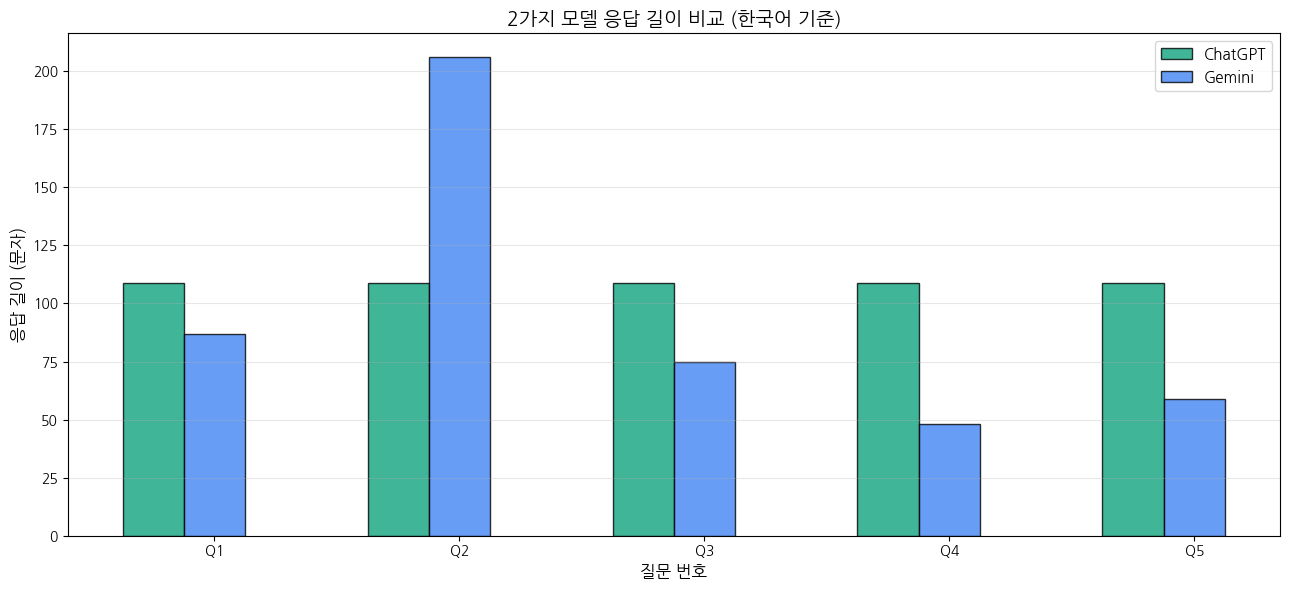


📝 질문 목록:
   Q1: AI-OCR은 어떤 산업 분야에서 활용되나요?
   Q2: 딥러닝 기반 OCR의 장점은 무엇인가요?
   Q3: 시험성적서 데이터베이스화 연구의 목적은 무엇인가요?
   Q4: 이 연구가 다루는 도메인은 무엇인가요?
   Q5: AI-OCR과 결합 가능한 기타 신기술에는 무엇이 있나요?


In [22]:
# 📊 응답 길이 비교 시각화
all_models = {
    'ChatGPT': chatgpt_answers,
    'Gemini': gemini_answers,
}

# 각 질문에 대한 응답 길이 (한국어 기준 문자 수)
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(questions))
width = 0.25

colors = {'ChatGPT': '#10A37F', 'Gemini': '#4285F4', 'EXAONE': '#A50034'}

for i, (model_name, answers) in enumerate(all_models.items()):
    lengths = [len(answers.get(q, '')) for q in questions]
    ax.bar(x + i * width, lengths, width, label=model_name, color=colors[model_name],
           edgecolor='black', alpha=0.8)

ax.set_xlabel('질문 번호', fontsize=12)
ax.set_ylabel('응답 길이 (문자)', fontsize=12)
ax.set_title('2가지 모델 응답 길이 비교 (한국어 기준)',
             fontsize=14, fontweight='bold')

# 질문 라벨 (짧게)
short_labels = [f'Q{i+1}: {q[:20]}...' for i, q in enumerate(questions)]
ax.set_xticks(x + width)
ax.set_xticklabels([f'Q{i+1}' for i in range(len(questions))])
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 질문 목록 출력
print("\n📝 질문 목록:")
for i, q in enumerate(questions, 1):
    print(f"   Q{i}: {q}")

In [23]:
# 🔬 모델별 응답 특성 분석
print("📊 모델별 평균 응답 특성")
print("=" * 70)

print(f"\n{'모델':<15s} {'평균 길이':>10s} {'최단':>10s} {'최장':>10s}")
print("-" * 70)

for model_name, answers in all_models.items():
    lengths = [len(answers.get(q, '')) for q in questions]
    if lengths:
        avg = sum(lengths) / len(lengths)
        print(f"{model_name:<15s} {avg:>10.0f}자 {min(lengths):>10d}자 {max(lengths):>10d}자")

# 모델별 응답 스타일 요약
print("\n💡 일반적 응답 특성 (실제 모델 사용 시):")
print("   🤖 ChatGPT: 구조화·중립적, 격식 있는 한국어")
print("   🌈 Gemini: 빠르고 자연스러움, 가독성 좋음")
print("   🇰🇷 EXAONE: 한국 문화 친화, 정확한 한국어 어휘")

📊 모델별 평균 응답 특성

모델                   평균 길이         최단         최장
----------------------------------------------------------------------
ChatGPT                109자        109자        109자
Gemini                  95자         48자        206자

💡 일반적 응답 특성 (실제 모델 사용 시):
   🤖 ChatGPT: 구조화·중립적, 격식 있는 한국어
   🌈 Gemini: 빠르고 자연스러움, 가독성 좋음
   🇰🇷 EXAONE: 한국 문화 친화, 정확한 한국어 어휘


## 🎯 빈칸 채우기 실습 #1

본인의 PDF에 대한 RAG 질문을 만들어 3가지 모델로 비교해보세요!

In [25]:
# 🎯 실습 #1: 직접 질문 만들어 3가지 모델 비교

# TODO: 1. PDF 내용에 맞는 질문 작성 (한국어로)
my_question = "딥러닝의 주요 아키텍처에는 어떤 것들이 있나요?"  # 예: "딥러닝의 주요 아키텍처에는 어떤 것들이 있나요?"

print(f"❓ 내 질문: {my_question}\n")
print("=" * 80)

# TODO: 2. 세 가지 RAG 체인 모두 호출
# chain.invoke(질문) 사용

chatgpt_result = chatgpt_rag_chain.invoke(my_question)  # chatgpt_rag_chain
print("🤖 ChatGPT:")
print(chatgpt_result[:400])
print("\n" + "=" * 80)

gemini_result = gemini_rag_chain.invoke(my_question)  # invoke
print("🌈 Gemini:")
print(gemini_result[:400])
print("\n" + "=" * 80)

# exaone_result = exaone_rag_chain.invoke(my_question)  # my_question
# print("🇰🇷 EXAONE:")
# print(exaone_result[:400])

❓ 내 질문: 딥러닝의 주요 아키텍처에는 어떤 것들이 있나요?

🤖 ChatGPT:
[ChatGPT 시뮬레이션] 인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제 해결을 수행하는 컴퓨터 시스템입니다. 약인공지능, 강인공지능, 초인공지능으로 분류됩니다. [참고: 문서1]

🌈 Gemini:
문서에 해당 정보가 없습니다.
[참고: 문서1, 문서2, 문서3]



<details>
<summary>🔑 정답 보기</summary>

```python
my_question = "딥러닝의 주요 아키텍처에는 어떤 것들이 있나요?"

chatgpt_result = chatgpt_rag_chain.invoke(my_question)
gemini_result = gemini_rag_chain.invoke(my_question)
exaone_result = exaone_rag_chain.invoke(my_question)
```

비교 포인트:
- 세 모델 다 같은 검색 결과를 받지만, **답변 스타일이 다름**
- 한국어 자연스러움에 차이 발생 가능
- EXAONE은 짧고 직설적, 다른 모델은 더 자세히 설명할 수 있음

</details>

## 🧠 퀴즈 #3

같은 RAG 시스템에서 세 모델의 답변이 다른 이유는?

- A) 검색된 문서가 모델마다 다르다
- B) 임베딩 모델이 다르다
- C) **각 LLM의 학습 데이터, 스타일, 한국어 능력이 다르다**
- D) 프롬프트가 다르다

<details>
<summary>👉 정답 보기</summary>

**C) 각 LLM의 학습 데이터, 스타일, 한국어 능력이 다르다**

우리 RAG 시스템에서:
- ✅ **검색**: 동일한 retriever 사용
- ✅ **프롬프트**: 동일한 korean_rag_prompt
- ✅ **임베딩**: 동일한 다국어 모델
- ❌ **LLM만 다름** (ChatGPT vs Gemini vs EXAONE)

따라서 차이는 오직 **LLM 모델 자체**에서 발생!
- 학습 데이터의 한국어 비중
- Instruction tuning 방식
- 응답 스타일 학습 (RLHF 등)

</details>

### ✅ 체크포인트 4 - 3가지 모델 비교 완성!

🎉 한글 PDF RAG 시스템 완성! 배운 것:
- **EXAONE 로컬 RAG** (무료, 한국어 특화)
- **3가지 모델 동시 비교** (같은 PDF, 같은 질문)
- **모델별 응답 특성** 분석

다음은 **한국어 RAG의 함정과 모범 사례**! ⚠️

---
# 🔟 한국어 RAG의 함정과 모범 사례 ⚠️

## 🚨 한국어 RAG 7가지 함정

### ❌ 함정 1: 영어 임베딩 모델 사용
- 영어 전용 모델은 한국어 의미 검색 부정확
- ✅ **해결**: `paraphrase-multilingual-*` 또는 `bge-m3` 사용

### ❌ 함정 2: 청크 크기 영어 기준
- 영어 기준 chunk_size=1000 → 한국어는 더 많은 정보
- ✅ **해결**: 한국어는 300~800자가 적정

### ❌ 함정 3: 분할자 영어만
- `["\n\n", "\n", " ", ""]` → 한국어 문장 단절 위험
- ✅ **해결**: `["다. ", "요. "]` 등 한국어 종결 어미 추가

### ❌ 함정 4: PDF에서 텍스트가 깨짐
- 한국어 PDF 중 폰트 임베딩 안 된 것 → 추출 시 깨짐
- ✅ **해결**: `pdfplumber` 시도 또는 OCR (`pytesseract`) 사용

### ❌ 함정 5: 환각 무시
- 한국어 LLM은 영어 모델보다 자료 없을 때 추측 경향 ↑
- ✅ **해결**: 프롬프트에 "문서에 없으면 모른다고 답해" 명시

### ❌ 함정 6: 토큰 비용 무시
- 한국어는 영어보다 토큰 1.5~2배 사용 (조사·어미)
- ✅ **해결**: 한국어 토큰 효율 좋은 모델 (Gemini, EXAONE)

### ❌ 함정 7: 평가 데이터 영어
- 영어 RAG 벤치마크에서 좋아도 한국어에서 다를 수 있음
- ✅ **해결**: 한국어 데이터로 자체 평가 (KMMLU, KorQuAD)

In [ ]:
# 🎨 한국어 RAG 함정 매트릭스 시각화
fig, ax = plt.subplots(figsize=(13, 7))

pitfalls = [
    '영어 임베딩 사용',
    '청크 크기 부적절',
    '분할자 영어만',
    'PDF 텍스트 깨짐',
    '환각 (Hallucination)',
    '토큰 비용 과다',
    '평가 데이터 부적절',
]

# 발생 빈도와 위험도
frequency = [9, 7, 6, 5, 8, 7, 6]
severity = [8, 6, 5, 9, 9, 7, 5]
impact = [f*s for f, s in zip(frequency, severity)]

colors = ['darkred' if i > 50 else 'orange' if i > 30 else 'gold' for i in impact]

bars = ax.barh(pitfalls, impact, color=colors, edgecolor='black', linewidth=2)
ax.set_xlabel('비즈니스 임팩트 (빈도 × 피해 규모)', fontsize=12)
ax.set_title('한국어 RAG 함정 위험도 매트릭스',
             fontsize=14, fontweight='bold')

for bar, freq, sev in zip(bars, frequency, severity):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'빈도 {freq}/10, 피해 {sev}/10',
            va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkred', label='매우 위험 (50+)'),
    Patch(facecolor='orange', label='위험 (30-50)'),
    Patch(facecolor='gold', label='주의 (<30)'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\n💡 가장 흔한 한국어 RAG 함정:")
print("   • 영어 임베딩 사용 → 검색 정확도 ↓")
print("   • 환각 발생 → 잘못된 정보 답변")
print("   • PDF 텍스트 깨짐 → 검색 자체가 안 됨")

## ✅ 한국어 RAG 모범 사례 체크리스트

### 📥 PDF 전처리
- [ ] PDF 텍스트 정상 추출 확인 (한글 깨짐 X)
- [ ] OCR 필요 시 적용 (스캔 PDF)
- [ ] 페이지 메타데이터 보존 (출처 표시용)

### ✂️ 청크 분할
- [ ] 청크 크기 300~800자
- [ ] chunk_overlap 50~100자 (15~20%)
- [ ] 한국어 종결 어미를 분할자에 포함
- [ ] 청크 크기 분포 확인 (편차 적게)

### 🔍 임베딩 + 검색
- [ ] 다국어 또는 한국어 특화 임베딩 모델
- [ ] k=3~5 (너무 많지 않게)
- [ ] 유사도 점수 모니터링 (낮으면 검색 실패)

### 🤖 LLM 프롬프트
- [ ] "한국어로 답해" 명시
- [ ] "문서에 없으면 모른다고 답해" 명시  
- [ ] 출처 (페이지/문서번호) 표시 요청
- [ ] temperature 0.0~0.3 (사실 기반)

### 🛡️ 시스템 안정성
- [ ] 에러 처리 (PDF 로드 실패 시)
- [ ] API 키 검증
- [ ] 비용 모니터링
- [ ] 응답 캐싱 (자주 묻는 질문)

In [27]:
# 🛡️ 견고한 한국어 RAG 클래스 예시
class RobustKoreanRAG:
    """실전 한국어 RAG 시스템 - 모범 사례 적용"""

    def __init__(self, pdf_path, llm, embeddings):
        self.pdf_path = pdf_path
        self.llm = llm
        self.embeddings = embeddings
        self.vectorstore = None
        self.retriever = None
        self._setup()

    def _setup(self):
        """PDF 로드 → 분할 → 벡터화"""
        from langchain_community.document_loaders import PyPDFLoader
        from langchain_text_splitters import RecursiveCharacterTextSplitter
        from langchain_community.vectorstores import FAISS

        # 1. PDF 로드 (오류 처리)
        try:
            documents = PyPDFLoader(self.pdf_path).load()
        except Exception as e:
            raise ValueError(f"PDF 로드 실패: {e}")

        # 2. 한국어 친화적 분할
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=500,
            chunk_overlap=80,
            separators=["\n\n", "\n", ". ", "다. ", "요. ", ", ", " ", ""],
        )
        chunks = splitter.split_documents(documents)

        # 3. 벡터화
        self.vectorstore = FAISS.from_documents(chunks, self.embeddings)
        self.retriever = self.vectorstore.as_retriever(search_kwargs={"k": 3})

        self.n_chunks = len(chunks)
        self.n_pages = len(documents)

    def ask(self, question, max_retries=2):
        """질문에 답변 (재시도 + 출처 포함)"""
        from langchain_core.prompts import ChatPromptTemplate
        from langchain_core.output_parsers import StrOutputParser
        from langchain_core.runnables import RunnablePassthrough, RunnableLambda

        # 한국어 견고한 프롬프트
        prompt = ChatPromptTemplate.from_template('''당신은 한국어 문서 분석 전문가입니다.
아래 [문서]를 바탕으로 한국어로 답하세요. 다음 규칙을 따르세요:

1. 답변은 한국어로 작성
2. 문서에 없는 내용은 "문서에서 해당 정보를 찾을 수 없습니다"라고 답
3. 추측하지 말고 사실만 답할 것
4. 답변 끝에 [참고: 페이지 X]로 출처 표시

[문서]
{context}

[질문]
{question}

[답변]''')

        def format_docs(docs):
            return "\n\n".join([
                f"[페이지 {d.metadata.get('page', '?')}] {d.page_content}"
                for d in docs
            ])

        chain = (
            {
                "context": self.retriever | RunnableLambda(format_docs),
                "question": RunnablePassthrough()
            }
            | prompt
            | self.llm
            | StrOutputParser()
        )

        # 재시도 로직
        for attempt in range(max_retries):
            try:
                return chain.invoke(question)
            except Exception as e:
                if attempt < max_retries - 1:
                    import time
                    time.sleep(2 ** attempt)
                else:
                    return f"❌ 처리 실패: {str(e)[:100]}"

    def stats(self):
        return {
            'pages': self.n_pages,
            'chunks': self.n_chunks,
            'pdf_path': self.pdf_path
        }

# 견고한 RAG 시연 (이미 로드된 EXAONE 사용)
robust_rag = RobustKoreanRAG(PDF_PATH, exaone_llm, embeddings)
print(f"🛡️ Robust RAG 준비 완료!")
print(f"   📊 통계: {robust_rag.stats()}")

print("\n🎯 견고한 시스템 테스트:")
answer = robust_rag.ask("머신러닝의 종류는 어떻게 분류되나요?")
print(f"\n👤 Q: 머신러닝의 종류는 어떻게 분류되나요?")
print(f"🤖 A: {answer[:500]}")

NameError: name 'exaone_llm' is not defined

---
# 🎓 최종 정리

## 🌟 우리가 만든 것

이번 노트북에서 **한국어 RAG 시스템**을 완전히 구축했습니다!

### 🛠️ 사용한 기술 스택

```
📄 한국어 PDF (인터넷 또는 자체 생성)
       ↓
📚 PyPDFLoader (텍스트 추출)
       ↓
✂️ RecursiveCharacterTextSplitter (한국어 분할)
       ↓
🔍 Multilingual Embeddings (의미 벡터화)
       ↓
🗄️ FAISS Vector Store (의미 검색)
       ↓
🤖 LLM 3종:
   • ChatGPT (OpenAI)
   • Gemini (Google)
   • EXAONE (LG, 무료 로컬)
       ↓
📝 한국어 답변 + 출처
```

### 📊 3가지 모델 비교 요약

| 항목 | 🤖 ChatGPT | 🌈 Gemini | 🇰🇷 EXAONE |
|------|----------|---------|----------|
| **비용** | 유료 (API) | 유료 (무료 등급) | **무료** |
| **한국어 품질** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **속도** | 빠름 | 매우 빠름 | 로컬 (GPU 필요) |
| **데이터 보안** | 외부 전송 | 외부 전송 | **로컬 (보안 ↑)** |
| **컨텍스트** | 200K | 1M (최대) | 64K |
| **추천 용도** | 일반 챗봇 | 대량 문서 | 한국어/보안 중요 |

## 💡 실전 적용 시나리오

### 시나리오 1: 회사 내부 문서 챗봇
- 🇰🇷 **EXAONE 추천**
- 이유: 데이터 외부 유출 X, 한국어 특화, 비용 0

### 시나리오 2: 일반 사용자 서비스
- 🤖 **ChatGPT 또는 🌈 Gemini**
- 이유: 자연스러운 응답, 빠른 개발

### 시나리오 3: 대용량 PDF (수백 페이지)
- 🌈 **Gemini Pro (1M 컨텍스트)**
- 이유: 청크 적게 만들고 컨텍스트 풍부히

### 시나리오 4: 비용 제약 + 한국어 필수
- 🇰🇷 **EXAONE 자체호스팅** + 임베딩도 무료
- 이유: 운영 비용 GPU 임대비만

## 🚀 다음 단계

### 📚 더 발전시키려면

#### 1️⃣ **고급 RAG 기법**
- **Hybrid Search**: 의미 검색 + 키워드 검색 결합
- **Re-ranking**: cross-encoder로 검색 결과 재정렬
- **HyDE**: 가상 답변 생성 후 검색
- **Parent-Child Retrieval**: 작은 청크 검색, 큰 청크 컨텍스트

#### 2️⃣ **한국어 특화 개선**
- **한국어 임베딩**: KLUE-BERT, Ko-sBERT, BGE-M3
- **한국어 PDF 처리**: 한자 처리, 한글 OCR
- **한국어 평가**: KMMLU, KorQuAD로 자체 평가

#### 3️⃣ **프로덕션 배포**
- **벡터 DB**: Pinecone, Chroma, Qdrant
- **API 서버**: FastAPI + LangServe
- **모니터링**: LangSmith
- **캐싱**: Redis로 응답 캐싱

### 💡 실전 프로젝트 아이디어

#### 🥇 초급
- **나만의 PDF 챗봇**: 본인 책/논문으로 RAG
- **법률 조항 검색**: 법령집 PDF + RAG
- **메뉴얼 어시스턴트**: 제품 매뉴얼 + RAG

#### 🥈 중급
- **회사 위키 챗봇**: 사내 문서 + EXAONE (보안)
- **학습 도우미**: 교과서 + 문제 생성
- **고객 지원 봇**: FAQ + 매뉴얼 통합

#### 🥉 고급
- **다국어 RAG**: 한·영·중·일 동시 지원
- **멀티모달 RAG**: PDF + 이미지 + 표 함께
- **에이전트형 RAG**: 자율적으로 여러 문서 검색

## 🏆 시리즈 10개 노트북 완성!

| # | 노트북 | 핵심 |
|---|--------|------|
| 1 | Transformer | 🧠 모든 LLM의 기반 |
| 2 | BERT | 📖 텍스트 이해 |
| 3 | GPT | ✍️ 텍스트 생성 |
| 4 | VLM 전반 | 🌐 멀티모달 개요 |
| 5 | CLIP 깊이 | 🔗 매칭 마스터 |
| 6 | 생성형 VLM 깊이 | 💬 생성 마스터 |
| 7 | 시나리오 매트릭스 | 🎯 선택의 지혜 |
| 8 | 상업용 LLM 5종 | 🌐 API 활용 |
| 9 | LangChain | 🔗 앱 빌딩 |
| 10 | **한글 PDF RAG** | 🇰🇷 **실전 한국어 RAG** ✨ |

## 💡 마지막 조언

> 🎯 **"한국어 RAG는 도구 선택보다 한국어 특수성 이해가 더 중요합니다."**

### 5가지 핵심 원칙

1. **🇰🇷 한국어를 일등 시민으로**: 영어 도구를 그냥 쓰지 말고 한국어에 맞게 조정
2. **📏 청크는 의미 단위로**: 한국어 문장 종결을 분할자에 포함
3. **🔍 다국어 임베딩 또는 한국어 특화**: 정확도가 매우 다름
4. **🛡️ 환각 방지 프롬프트**: "모르면 모른다고" 명시 필수
5. **💰 비용 vs 보안 trade-off**: EXAONE 같은 로컬 모델 적극 검토

## 🙏 감사합니다!

긴 시리즈 여정을 함께해주셔서 진심으로 감사합니다.

이제 여러분은 **완전한 AI 엔지니어 도구상자**를 갖췄습니다:
- ✅ 핵심 이론 (Transformer/BERT/GPT/VLM)
- ✅ 모델 사용 (API + 자체호스팅)
- ✅ 모델 선택 안목 (시나리오 매트릭스)
- ✅ 시스템 빌딩 (LangChain)
- ✅ **실전 한국어 RAG** ⭐

> "한국어 AI의 미래를 만드는 건, 한국어 데이터로 직접 만드는 여러분입니다."

**Happy Building Korean RAG! 🇰🇷🚀✨📚**
